# Load Libs

In [20]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns


# custom functions
from Functions.functions import (download_data,
                        load_data,
                        Preprocessor,
                        split_time,
                        windowed_dataset,
                        create_target_df)

In [35]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [2]:
load_col = 'val_cargaenergiamwmed'
time_col = 'din_instante'
regiao = 'SUDESTE'

batch_size = 32
# target days to sum into weeks
target_period = 7 
# number of weeks in the window
n_weeks_ws = 20
# window size in days for each row
window_size = 7*n_weeks_ws
filepath = 'Models/Model_v1.h5'
shuffle_buffer = 20
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load data

In [10]:
df_20XX = load_data(start=2009, end=2021)
df_20XX.tail()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
18988,SE,SUDESTE,2021-12-30,38850.805500
18989,N,NORTE,2021-12-31,5396.575583
18990,NE,NORDESTE,2021-12-31,10835.873958
18991,S,SUL,2021-12-31,10689.669167
18992,SE,SUDESTE,2021-12-31,35249.151750


# Preprocess data

In [11]:
pp = Preprocessor(regiao='SUDESTE')
df = pp.fit_transform(df_20XX)
df.tail(8)

No missing NaN.

Missing days in the series:
DatetimeIndex(['2016-04-01', '2016-04-02', '2016-04-03', '2016-04-04',
               '2016-04-05', '2016-04-06', '2016-04-07', '2016-04-08',
               '2016-04-09', '2016-04-10', '2016-04-11', '2016-04-12',
               '2016-04-13', '2016-04-14'],
              dtype='datetime64[ns]', freq=None)


,din_instante,val_cargaenergiamwmed,semana,dia semana,dia mes,Mes,ano
4724,2021-12-23,40538.381833,674,Thursday,23,12,2021
4725,2021-12-24,35745.640917,675,Friday,24,12,2021
4726,2021-12-25,31276.821042,675,Saturday,25,12,2021
4727,2021-12-26,33942.445250,675,Sunday,26,12,2021
4728,2021-12-27,39736.502167,675,Monday,27,12,2021
4729,2021-12-28,40201.573667,675,Tuesday,28,12,2021
4730,2021-12-29,40083.157792,675,Wednesday,29,12,2021
4731,2021-12-30,38850.805500,675,Thursday,30,12,2021


# Split Data

In [12]:
# index of end of training dataset, start of validation dataset
split_val = int(len(df)*0.7)
# index of end of validation dataset, start of test dataset
split_test = int(len(df)*0.9)
# date when starts the validation and test sets 
date_val = df.iloc[split_val][time_col]
date_test = df.iloc[split_test][time_col]
# window_size date interval
delta_window = pd.to_timedelta(window_size,unit='d')
# split validation data date + window_size
d2 = date_val + delta_window
# split test data date + window_size
d3 = date_test + delta_window 

In [13]:
train_df, val_df, test_df = split_time(split_val = split_val, 
                                       split_test = split_test,
                                       df=df_20XX,
                                       regiao=regiao)

No missing NaN.

Missing days in the series:
DatetimeIndex(['2016-04-01', '2016-04-02', '2016-04-03', '2016-04-04',
               '2016-04-05', '2016-04-06', '2016-04-07', '2016-04-08',
               '2016-04-09', '2016-04-10', '2016-04-11', '2016-04-12',
               '2016-04-13', '2016-04-14'],
              dtype='datetime64[ns]', freq=None)
No missing NaN.

Missing days in the series:
DatetimeIndex(['2016-04-01', '2016-04-02', '2016-04-03', '2016-04-04',
               '2016-04-05', '2016-04-06', '2016-04-07', '2016-04-08',
               '2016-04-09', '2016-04-10', '2016-04-11', '2016-04-12',
               '2016-04-13', '2016-04-14'],
              dtype='datetime64[ns]', freq=None)
No missing NaN.

No missing days in the series
No missing NaN.

No missing days in the series


# Process Data 

In [14]:
# dataset to training
train_dataset, train_data_week = windowed_dataset(df = train_df,
                                                batch_size = batch_size, 
                                                window_size = window_size, 
                                                shuffle_buffer = shuffle_buffer, 
                                                target_period = target_period,
                                                shuffle=True)
# dataset for performance evaluation
train_pred_dataset, train_pred_data_week = windowed_dataset(df = train_df, 
                                                            batch_size = batch_size, 
                                                            window_size = window_size, 
                                                            shuffle_buffer = shuffle_buffer, 
                                                            target_period = target_period,
                                                            shuffle=False)
val_dataset, val_data_week = windowed_dataset(df = val_df, 
                                            batch_size = batch_size, 
                                            window_size = window_size, 
                                            shuffle_buffer = shuffle_buffer, 
                                            target_period = target_period,
                                            shuffle=False)

test_dataset, test_data_week = windowed_dataset(df = test_df,
                                                batch_size = batch_size, 
                                                window_size = window_size, 
                                                shuffle_buffer = shuffle_buffer, 
                                                target_period = target_period,
                                                shuffle=False)

In [18]:
c=0
for x,y in train_dataset:
  #print('x=', x)
  #print('y=', y)
  c +=1
print(c*batch_size)

480


# Target

In [23]:
df_target = create_target_df(df)
df_target.tail(3)

,val_cargaenergiamwmed,Data,dia semana,baseline
semana,,,,
673,41609.216357,2021-12-10,Friday,40152.501982
674,39992.943000,2021-12-17,Friday,41609.216357
675,37119.563762,2021-12-24,Friday,39992.943000


# Baseline

In [24]:
# indexes for .loc for each set of data 
train_ix_base = ((df_target['Data'] < date_val) & (df_target['Data'] >= '2009-05-22'))
val_ix_base = ((df_target['Data'] > d2) & (df_target['Data']<date_test))
test_ix_base = df_target['Data']> d3


# metrics for baseline model
metrics_baseline = pd.DataFrame(index = ['train', 'val', 'test'], 
                       data = 

          {'MAE' : [tf.keras.metrics.mean_absolute_error(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],
           
          'MAPE' : [tf.keras.metrics.mape(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],
           
          'MSE' : [tf.keras.metrics.mse(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],

          'MSLE' : [tf.keras.metrics.msle(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],

          'RMSE' : [tf.keras.metrics.RootMeanSquaredError().update_state(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]]          
          })

metrics_baseline

,MAE,MAPE,MSE,MSLE,RMSE
train,1070.513151,3.021482,2.067040e+06,0.001621,453.0
val,1280.296477,3.455976,3.044019e+06,0.002138,114.0
test,1004.067470,2.566258,1.735302e+06,0.001117,46.0


# train model

In [26]:
def compile_and_fit(model, data, val_data, epochs,optimizer,
                    filepath=filepath, patience=4):
  # early stopping callback
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')
  # checkpoint callback
  checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath = filepath, monitor = 'loss', 
                               verbose = 1, save_best_only = True, mode = 'min')
  
  # compile
  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=optimizer,
                metrics=[tf.metrics.MeanAbsoluteError(),
                         tf.metrics.MeanAbsolutePercentageError(),
                         tf.keras.metrics.RootMeanSquaredError()])
  # fit data
  history = model.fit(data, epochs=epochs, verbose=1,
                      validation_data= val_data,
                      callbacks=[early_stopping, checkpoint])
  return history

{'n_layers': 2, 'n_units_l0': 23, 'n_units_l1': 59, 'optimizer': 'Adam', 'adam_learning_rate': 0.008260539609105095}

In [66]:
weight_decay = 5.29435315233284e-06

optimizer = tf.optimizers.Adam(learning_rate=0.00826053961) #Adagrad(learning_rate= 0.9580, epsilon = 2.645-08)

l0 = tf.keras.layers.LSTM(8, return_sequences=False, 
#                          kernel_regularizer=tf.keras.regularizers.l2(weight_decay),
#                          recurrent_dropout = 0.2,
                          activation ='tanh')
l1 = tf.keras.layers.LSTM(8, return_sequences=False, 
#                          kernel_regularizer=tf.keras.regularizers.l2(weight_decay), 
#                          recurrent_dropout = 0.2,
                          activation ='tanh')

# LSTM
model = tf.keras.models.Sequential([
    tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis = -1), input_shape=[None]),
    tf.keras.layers.BatchNormalization(),
    l0,
    #l1,
    tf.keras.layers.Dense(1), #, kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Lambda(lambda x: x * 10000.0)
    ])


history = compile_and_fit(model, epochs = 200, 
                          data=train_dataset, 
                          val_data = val_dataset,
                          optimizer = optimizer,
                          patience = 50,
                          filepath = filepath)

#print(os.listdir())

#print("Layer weights {}".format(l0.get_weights())) 

Epoch 1/200
     13/Unknown - 5s 34ms/step - loss: 978696256.0000 - mean_absolute_error: 31183.0762 - mean_absolute_percentage_error: 89.5076 - root_mean_squared_error: 31284.1211 
Epoch 1: loss improved from inf to 954100992.00000, saving model to Models\Model_v1.h5
15/15 [==============================] - 5s 88ms/step - loss: 954100992.0000 - mean_absolute_error: 30755.9629 - mean_absolute_percentage_error: 88.0884 - root_mean_squared_error: 30888.5254 - val_loss: 548247488.0000 - val_mean_absolute_error: 23229.3984 - val_mean_absolute_percentage_error: 63.7745 - val_root_mean_squared_error: 23414.6855
Epoch 2/200
15/15 [==============================] - ETA: 0s - loss: 293838368.0000 - mean_absolute_error: 16832.3965 - mean_absolute_percentage_error: 48.2512 - root_mean_squared_error: 17141.7148
Epoch 2: loss improved from 954100992.00000 to 293838368.00000, saving model to Models\Model_v1.h5
15/15 [==============================] - 1s 40ms/step - loss: 293838368.0000 - mean_absolut

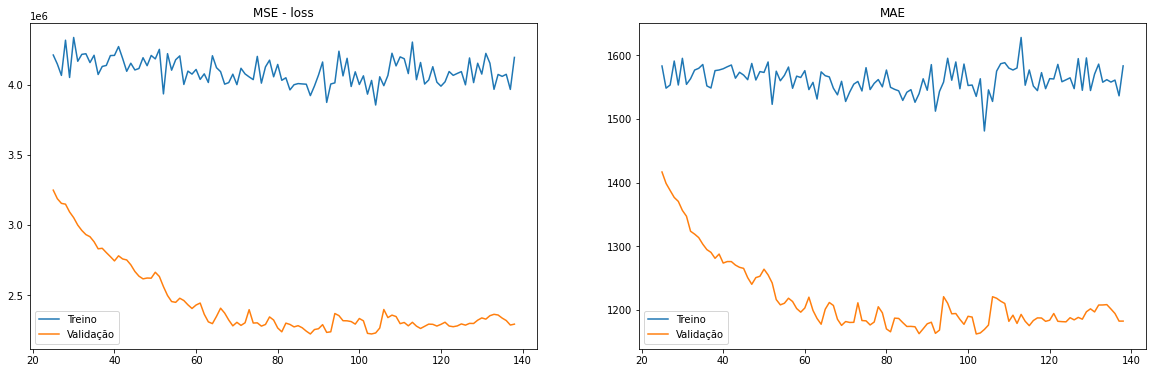

In [67]:
# evaluate training metrics

# starting epoch to plot
skip = 25

fig,ax = plt.subplots(figsize=(20,6), nrows=1, ncols=2)
metrics_list = ['loss',
                'val_loss',
                'mean_absolute_error', 
                'val_mean_absolute_error'
                ]

for i, metric in enumerate(metrics_list):
  if i<=1:
    ax1 =  ax.ravel()[0]
  else:
    ax1 =  ax.ravel()[1]
  sns.lineplot(x = range(skip,len(history.history[metric])),
              y = history.history[metric][skip:],
              ax = ax1)


ax.ravel()[0].set_title("MSE - loss")
ax.ravel()[0].legend(labels=['Treino', 'Validação'])
ax.ravel()[1].set_title("MAE")
ax.ravel()[1].legend(labels=['Treino', 'Validação'])

plt.show()

2/2 [==============================] - 0s 48ms/step - loss: 1740972.1250 - mean_absolute_error: 1033.8972 - mean_absolute_percentage_error: 2.5993 - root_mean_squared_error: 1319.4590


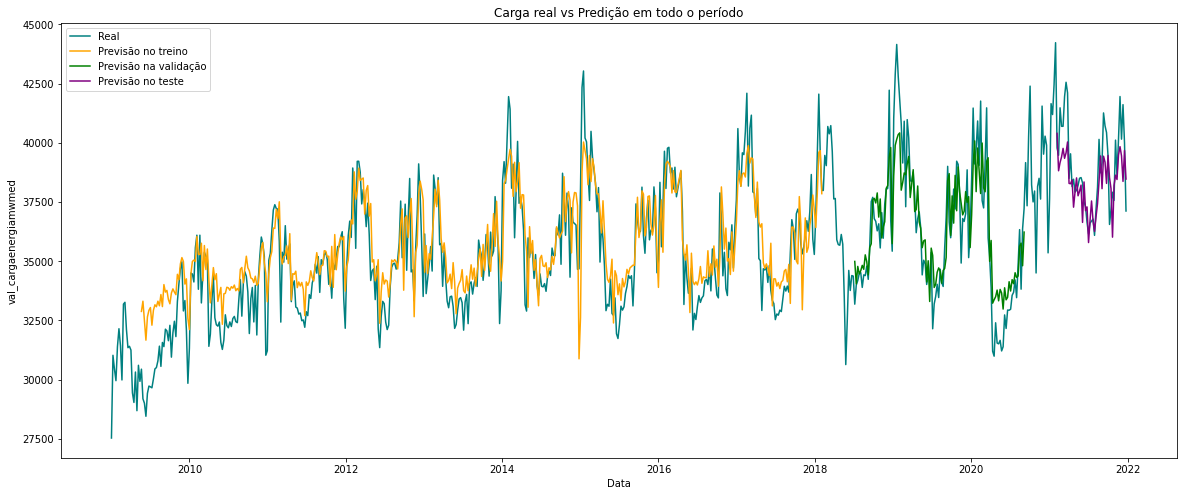

In [68]:
model.load_weights(filepath)

train_pred = model.predict(train_pred_dataset)[:, 0]
val_pred = model.predict(val_dataset)[:, 0]
test_pred = model.predict(test_dataset)[:, 0]

fix,ax=plt.subplots(figsize=(20, 8))

# plot measured data
sns.lineplot(x = df_target['Data'], 
             y = df_target[load_col], ax=ax, color = 'teal')

# plot predicted data
for date,pred,color in zip([train_pred_data_week,val_data_week,test_data_week], 
                           [train_pred, val_pred, test_pred],
                           ['orange', 'green', 'purple']): 
  sns.lineplot(x = date,
               y = pred, 
               ax=ax, 
               color=color)
#scores = f"MAE on val : {metrics_df.MAE.iloc[0]}"

plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 
            'Previsão no treino', 
            'Previsão na validação', 
            'Previsão no teste'])

# evaluate performance
train_performance = {}
train_performance['LSTM'] = model.evaluate(train_dataset)
val_performance = {}
val_performance['LSTM'] = model.evaluate(val_dataset)
performance = {}
performance['LSTM'] = model.evaluate(test_dataset,)

# Residual Analysis

In [15]:
#val_pred - df_target[(df_target['Data']>d2) & (df_target.Data<d3)]